# Exploratory Data Analysis

Contains X Sections:
1. Loan Size Prior Assessment
2. Industry Priors Assessment
3. Bivariate Analysis
 - Loan size + Default rate impact per NAICS sector
4. Assessment of Additional Model Features
 - Preliminary checks to further understand features to be used in the model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib import colors
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import scipy.stats

pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))

load_dotenv()
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
name = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}")
df = pd.read_sql_table('vw_loans_clean', engine, schema='sba')
df.shape

(348274, 13)

## Loan Size Prior Assessment

In [2]:
deciles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

decile_loan_size = []

for dec in deciles:
    value = np.quantile(df['gross_approval'], dec)
    integer = int(value)
    decile_loan_size.append(integer)

decile_loan_size


[15000, 25000, 50000, 65000, 100000, 150000, 250000, 401840, 864000]

In [3]:
df['gross_approval_decile'] = pd.qcut(df['gross_approval'], 10)
decile_chgoffs = df.groupby('gross_approval_decile')['is_default'].agg(['sum','count', 'mean']).reset_index() \
            .rename(columns={'sum': 'defaults', 'count': 'total_loans', 'mean': 'default_rate'})
decile_chgoffs

decile_chgoffs.style.format({'default_rate': '{:.2%}'})

,gross_approval_decile,defaults,total_loans,default_rate
0,"(999.999, 15000.0]",3619,36510,9.91%
1,"(15000.0, 25000.0]",3212,38775,8.28%
2,"(25000.0, 50000.0]",4023,54768,7.35%
3,"(50000.0, 65000.0]",691,10276,6.72%
4,"(65000.0, 100000.0]",2747,38626,7.11%
5,"(100000.0, 150000.0]",3179,34016,9.35%
6,"(150000.0, 250000.0]",2294,32426,7.07%
7,"(250000.0, 401840.0]",2496,33222,7.51%
8,"(401840.0, 864000.0]",2183,34838,6.27%
9,"(864000.0, 5000000.0]",1802,34817,5.18%


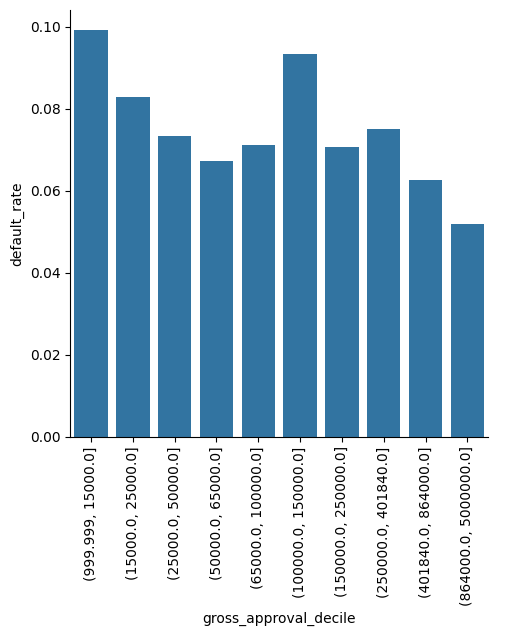

In [4]:
sns.catplot(data = decile_chgoffs, x = 'gross_approval_decile', y = 'default_rate', kind = 'bar')
plt.xticks(rotation=90)
plt.show()

In [5]:
outlier_decile = df[df['gross_approval_decile'] == pd.Interval(left = 100000, right = 150000, closed='right')]

outlier_decile.groupby('naics_sector_description')['is_default'] \
    .agg(np.sum).sort_values(ascending=False)

naics_sector_description
Retail Trade                                                                526
Accommodation and Food Services                                             466
Other Services (except Public Administration)                               353
Construction                                                                310
Professional, Scientific, and Technical Services                            284
Manufacturing                                                               241
Health Care and Social Assistance                                           185
Wholesale Trade                                                             183
Administrative and Support and Waste Management and Remediation Services    171
Arts, Entertainment, and Recreation                                         141
Transportation and Warehousing                                              131
Educational Services                                                         63
Finance and Ins

In [6]:
df[df['gross_approval_decile'] != pd.Interval(100000, 150000, closed='right')].groupby('naics_sector_description')['is_default'].agg(np.sum) \
    .sort_values(ascending=False)

naics_sector_description
Retail Trade                                                                3768
Accommodation and Food Services                                             3326
Construction                                                                2533
Professional, Scientific, and Technical Services                            2073
Other Services (except Public Administration)                               1994
Manufacturing                                                               1682
Wholesale Trade                                                             1480
Health Care and Social Assistance                                           1477
Transportation and Warehousing                                              1412
Administrative and Support and Waste Management and Remediation Services    1019
Arts, Entertainment, and Recreation                                          774
Real Estate and Rental and Leasing                                           337
Inf

In [7]:
outlier_decile['gross_approval'].value_counts().head(15)

gross_approval
150,000.00    16410
125,000.00     2315
120,000.00     1418
140,000.00      934
130,000.00      886
110,000.00      813
135,000.00      714
115,000.00      530
145,000.00      451
105,000.00      450
144,000.00      203
108,000.00      191
149,000.00      184
112,000.00      165
128,000.00      151
Name: count, dtype: int64

In [8]:
df[df['gross_approval'] == 150000].groupby('gross_approval')[['is_default']].mean() \
    .rename(columns={'is_default': 'default_rate'}).style.format({'default_rate': '{:.2%}'})

,default_rate
gross_approval,
150000.000000,11.63%


In [9]:
outlier_decile[outlier_decile['gross_approval'] != 150000][['is_default']].mean().to_frame() \
    .rename(index={'is_default': 'gross_approval below $150K'}, columns={0: 'default_rate'}).style.format({'default_rate': '{:.2%}'})

,default_rate
gross_approval below $150K,7.21%


### Section Findings
- **My prior expecting larger loans to exhibit higher default rates was incorrect.** Loan size does have an effect on the default rate, but smaller loans exhibit higher risk while larger loans show lower risk. Borrowers applying for larger loans likely undergo a more rigorous vetting process than those requesting smaller loans. Companies which are requesting and approved for larger loans likely have demonstrated higher viability and stable cash flows while potentially having more years in business on average (this can not be verified due to a high percentage of nulls in business_age).

- My expectation was that smaller businesses would struggle with larger loans due to their volatility. Small businesses experience stronger impacts from fiscal/monetary policy and macroeconomic changes than mid- or large-cap companies, so I believed larger loans would have adverse effects on liquidity, leaving less of a cushion to defend against shocks that could push the company toward insolvency. (This prior was formed under the original FY2000-2019 scope, which spanned recessionary periods, and was carried over when the window narrowed to FY2010-2017.)

- Even with the significant range in the last decile, spanning over $4MM ($864K-$5MM), the default rate is still half that of the first decile, spanning $1K-$15K. 

- The $100K-$150K decile exhibited a default rate that broke the downward trend as loan size increased. Loans at $150K covered 48% of all loans in the decile, and displayed a default rate of 11.63%, substantially higher than the 7.21% default rate of the rest of the loans in the group. This decile also had an industry composition that aligned with the other deciles.

## Industry Priors Assessment

In [10]:
sector_chgoffs = df.groupby(['naics_sector_description'])['is_default'] \
    .agg(['sum','count', 'mean']).reset_index() \
    .sort_values(by='mean', ascending=False) \
    .rename(columns={'sum': 'defaults', 'count': 'total_loans'})

sector_chgoffs.style.format({'mean': '{:.2%}'})

,naics_sector_description,defaults,total_loans,mean
3,"Arts, Entertainment, and Recreation",915,9364,9.77%
14,Public Administration,6,62,9.68%
16,Retail Trade,4294,48763,8.81%
0,Accommodation and Food Services,3792,43171,8.78%
17,Transportation and Warehousing,1543,17913,8.61%
19,Wholesale Trade,1663,19414,8.57%
11,"Mining, Quarrying, and Oil and Gas Extraction",84,1062,7.91%
4,Construction,2843,36558,7.78%
12,Other Services (except Public Administration),2347,30338,7.74%
5,Educational Services,350,4562,7.67%


In [11]:
sector_default_spread = df.groupby(['naics_sector_description'])['is_default'].value_counts(normalize=True).unstack() \
                            .rename(columns={0: 'Non-default', 1: 'Default'})
                            
sector_default_spread.style.format({'Non-default': '{:.2%}', 'Default': '{:.2%}'})

is_default,Non-default,Default
naics_sector_description,,
Accommodation and Food Services,91.22%,8.78%
Administrative and Support and Waste Management and Remediation Services,92.59%,7.41%
"Agriculture, Forestry, Fishing and Hunting",94.88%,5.12%
"Arts, Entertainment, and Recreation",90.23%,9.77%
Construction,92.22%,7.78%
Educational Services,92.33%,7.67%
Finance and Insurance,95.72%,4.28%
Health Care and Social Assistance,94.88%,5.12%
Information,92.50%,7.50%


In [12]:
df['is_retail'] = df['naics_sector_description'] == 'Retail Trade'
retail_contingency_test = pd.crosstab(df['is_retail'], df['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
retail_contingency_test


is_default,Non-Default,Default
is_retail,,
False,277559,21952
True,44469,4294


In [13]:
scipy.stats.chi2_contingency(observed = retail_contingency_test)

Chi2ContingencyResult(statistic=np.float64(131.0020045305545), pvalue=np.float64(2.4735635840325614e-30), dof=1, expected_freq=array([[276939.78967135,  22571.21032865],
       [ 45088.21032865,   3674.78967135]]))

In [14]:
df['is_construction'] = df['naics_sector_description'] == 'Construction'
construction_contingency_test = pd.crosstab(df['is_construction'], df['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
construction_contingency_test

is_default,Non-Default,Default
is_construction,,
False,288313,23403
True,33715,2843


In [15]:
scipy.stats.chi2_contingency(observed = construction_contingency_test)

Chi2ContingencyResult(statistic=np.float64(3.356592394814604), pvalue=np.float64(0.06693644269380317), dof=1, expected_freq=array([[288225.01837059,  23490.98162941],
       [ 33802.98162941,   2755.01837059]]))

In [16]:
mean = df[['is_default']].mean()
mean = mean.rename(index={'is_default': 'mean'})

std = df[['is_default']].std(ddof=0)
std = std.rename(index={'is_default': 'std'})

pd.concat(
    [mean, std], axis = 0).to_frame() \
    .rename(columns={0: 'Weighted Mean/Std'}) \
    .style.format({'Weighted Mean/Std': '{:.2%}'}
    )

# Weighted by NAICS sector distribution.


,Weighted Mean/Std
mean,7.54%
std,26.40%


In [17]:
unweighted_mean = sector_chgoffs[['mean']].mean()

unweighted_std = sector_chgoffs[['mean']].std(ddof=0)
unweighted_std = unweighted_std.rename(index={'mean': 'std'})

pd.concat(
    [unweighted_mean, unweighted_std], axis = 0).to_frame() \
    .rename(columns={0: 'Unweighted Mean/Std'}) \
    .style.format({'Unweighted Mean/Std': '{:.2%}'}
    )

# Taking the mean of NAICS sector means removes the weighting, allowing all sectors to be equally represented.

,Unweighted Mean/Std
mean,7.10%
std,1.84%


In [18]:
# Determine how many stddevs the Retail sector default rate is from the unweighted mean

retail_sector_diff = sector_default_spread.loc['Retail Trade', 'Default'] - unweighted_mean.reset_index().iloc[0, 1]
retail_sector_diff / unweighted_std.reset_index().iloc[0, 1]

np.float64(0.9282528120445727)

In [19]:
# Repeat for construction

construction_sector_diff = sector_default_spread.loc['Construction', 'Default'] - unweighted_mean.reset_index().iloc[0, 1]
construction_sector_diff / unweighted_std.reset_index().iloc[0, 1]

np.float64(0.3691755028863649)

In [20]:
# Determine how many stddevs the Retail sector default rate is from the median

retail_diff_median = sector_default_spread.loc['Retail Trade', 'Default'] - np.quantile(sector_chgoffs['mean'], 0.5)
retail_diff_median / unweighted_std.reset_index().iloc[0, 1]

np.float64(0.6629527677436146)

In [21]:
# Repeat for construction

construction_diff_median = sector_default_spread.loc['Construction', 'Default'] - np.quantile(sector_chgoffs['mean'], 0.5)
construction_diff_median / unweighted_std.reset_index().iloc[0, 1]

np.float64(0.10387545858540673)

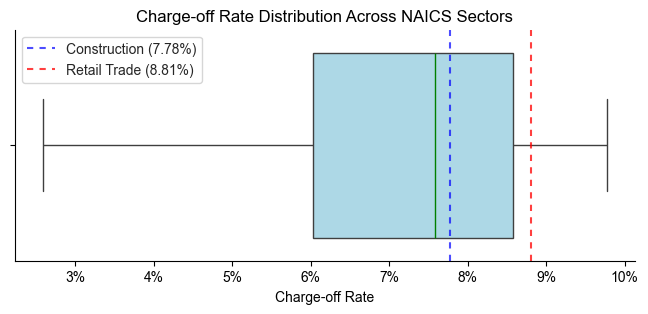

In [22]:
fig, ax = plt.subplots(figsize=(8, 3))
sns.set_style('whitegrid')
sns.boxplot(data = sector_chgoffs, x = 'mean',
            whis = 1.5, ax = ax,
            boxprops={'facecolor': 'lightblue'},
            medianprops={'color': 'g'})
ax.set_xlabel('Charge-off Rate')
ax.set_title('Charge-off Rate Distribution Across NAICS Sectors')
plt.axvline(x = 0.0778, dashes = (3, 3), color = ('blue', .7), label='Construction (7.78%)')
plt.axvline(x = 0.0881, dashes = (3, 3), color = ('red', .75), label='Retail Trade (8.81%)')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals = 0))
ax.legend()
sns.despine()
plt.show()

### Section Findings
Context:
 - The mean portfolio default rate is 7.54%, also referred to as the weighted mean (weighted by each NAICS sector's loan count).
 - The unweighted mean default rate is 7.10% (NAICS sectors equally weighted).
 - The unweighted median is 7.56% and is also used as a comparator since it has less influence from outliers.
 - Standard deviation is 1.84%, unweighted. Weighted stddev is not used.
 - For chi-square tests of independence, we will use the traditional value of 0.05 as our alpha.

#### Retail Prior
- Retail's mean default rate of 8.81% falls outside of the IQR, above the 75th percentile. It is nearly one standard deviation (0.93 stddevs) above the unweighted default rate mean of 7.10%, and exactly 1.25ppts above the unweighted median of 7.56%. The chi-square test of independence displays a very low p-value (2.47e-30), well below our alpha of 0.05, allowing us to reject the null hypothesis. The expected frequencies indicate that the Retail sector experienced 619 more defaults than if Retail had defaulted at the mean portfolio rate (weighted mean) of 7.54%.

- Retail experienced the third highest default rate amongst the NAICS sectors. Unexpectedly, Arts, Entertainment, and Recreation (AE&R) experienced the highest default rate. Retail Trade's data is more robust than AE&R's, however, with over 5 times more loans reported than AE&R's total, 9364. Public Administration's default rate is higher than Retail's, but the data is noisy due to their small sample size of 62 loans. I am unsure if these loans are anomalies or genuine. I'd expect a lower default rate for Public Admin; entities in this sector tend to pay slow due to government procedures/management chains, but non-payment is generally unlikely.

- **My prior expecting Retail to display higher than average default risk is accurate.**

#### Construction Prior
- Construction has a default rate of 7.78%, which is within the IQR, about 0.37 standard deviations higher than the average unweighted default rate and 0.22ppts above the unweighted median.

- We fail to reject the null hypothesis since our p-value is 0.067. However, this result is sensitive to the alpha; if we had chosen an alpha of 0.1 instead, we would reject the null, making this result borderline.

- Ultimately, while there is potential for a Type II error, **my prior in which I believed the Construction sector would display average default risk is supported by the results.**

---

Default rate sensitivity to loan size for the Retail and Construction sectors will be tested in the next section.

# Bivariate Analysis
- Loan size + Default Rate, per NAICS sector

In [23]:
mean_sector_approval = df.groupby(['naics_sector_description'])[['gross_approval']].mean().sort_values(by='gross_approval', ascending=False)
mean_sector_approval

,gross_approval
naics_sector_description,
"Agriculture, Forestry, Fishing and Hunting","536,350.23"
Management of Companies and Enterprises,"493,233.68"
Real Estate and Rental and Leasing,"485,527.83"
Accommodation and Food Services,"458,259.62"
"Mining, Quarrying, and Oil and Gas Extraction","432,988.14"
Wholesale Trade,"430,031.21"
Manufacturing,"420,101.91"
Health Care and Social Assistance,"377,147.00"
"Arts, Entertainment, and Recreation","355,530.07"


In [24]:
full_set = pd.merge(mean_sector_approval, sector_chgoffs, how = 'left', on = 'naics_sector_description') \
            .rename(columns={'mean': 'default_rate'})

full_set.style.format({'gross_approval': '{:.8}', 'default_rate': '{:.2%}'})

,naics_sector_description,gross_approval,defaults,total_loans,default_rate
0,"Agriculture, Forestry, Fishing and Hunting",536350.23,310,6058,5.12%
1,Management of Companies and Enterprises,493233.68,5,193,2.59%
2,Real Estate and Rental and Leasing,485527.83,370,7448,4.97%
3,Accommodation and Food Services,458259.62,3792,43171,8.78%
4,"Mining, Quarrying, and Oil and Gas Extraction",432988.14,84,1062,7.91%
5,Wholesale Trade,430031.21,1663,19414,8.57%
6,Manufacturing,420101.91,1923,28487,6.75%
7,Health Care and Social Assistance,377147.0,1662,32478,5.12%
8,"Arts, Entertainment, and Recreation",355530.07,915,9364,9.77%
9,Finance and Insurance,327533.77,246,5751,4.28%


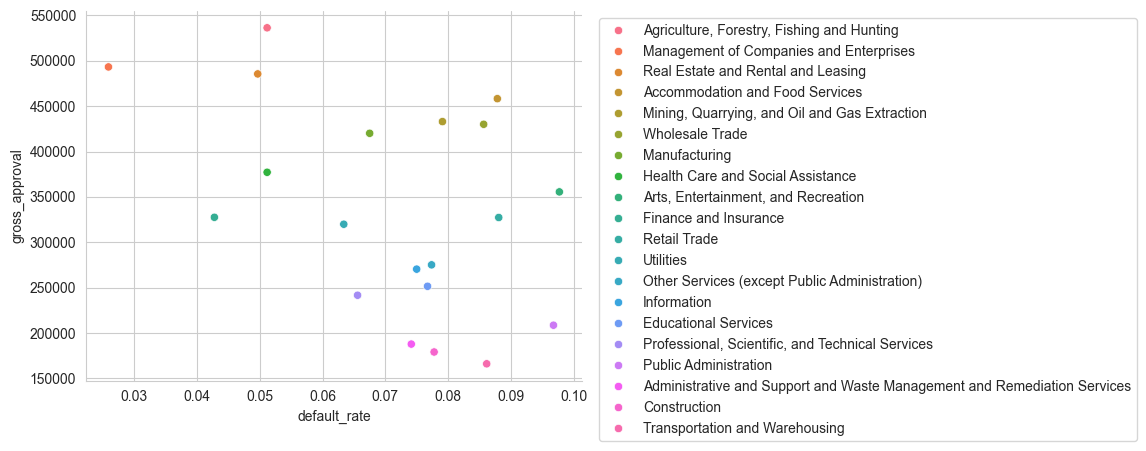

In [25]:
sns.set_style('whitegrid')
sns.scatterplot(
    data = full_set,
    x = 'default_rate',
    y = 'gross_approval',
    hue = 'naics_sector_description'
)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.show()

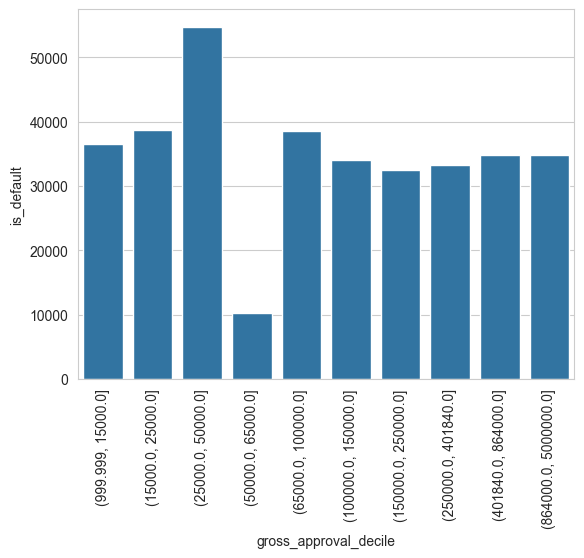

In [26]:
t = df.groupby('gross_approval_decile')['is_default'].agg('count')
sns.barplot(data = t)
plt.xticks(rotation=90)
plt.show()

In [27]:
max_small_mean = df[df['gross_approval'] == 350000]['is_default'].agg('mean')
max_small_count = df[df['gross_approval'] == 350000]['is_default'].agg('count')
print('Default Rate: ', max_small_mean)
print('Loan Count: ', max_small_count)

Default Rate:  0.08003467206009823
Loan Count:  6922


In [28]:
fifty_mean = df[df['gross_approval'] == 50000]['is_default'].agg('mean')
fifty_count = df[df['gross_approval'] == 50000]['is_default'].agg('count')
print('Default Rate: ', fifty_mean)
print('Loan Count: ', fifty_count)

Default Rate:  0.07917121897924145
Loan Count:  25628


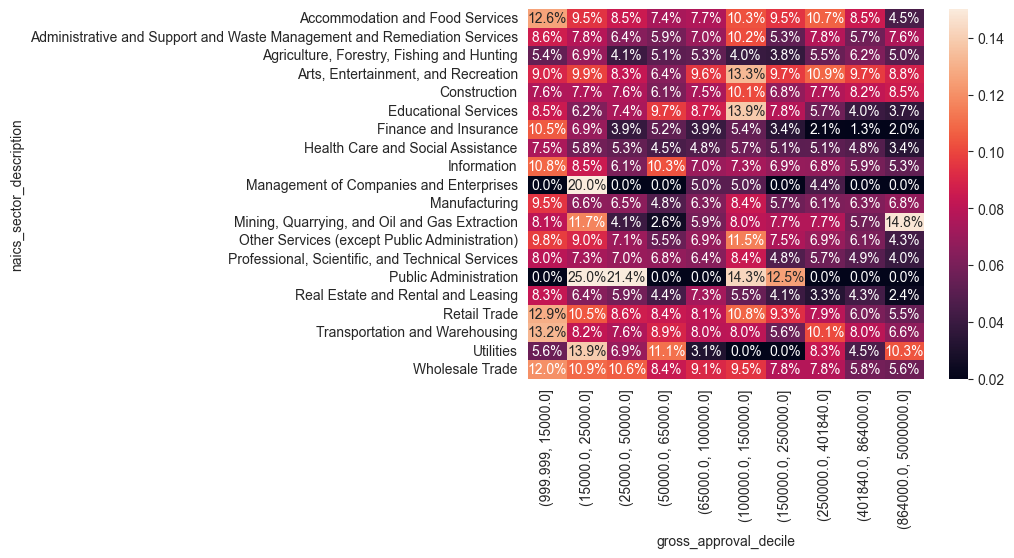

In [29]:
# Not a correlation heatmap.
default_rate_by_sector_decile = df.pivot_table(
    index = 'naics_sector_description',
    columns = 'gross_approval_decile',
    values = 'is_default',
    aggfunc = 'mean',
    fill_value = None
)

sns.heatmap(
    data = default_rate_by_sector_decile,
    cmap = 'rocket',
    vmin = 0.02,
    vmax = 0.15,
    annot = True, fmt = '.1%'
)

plt.show()

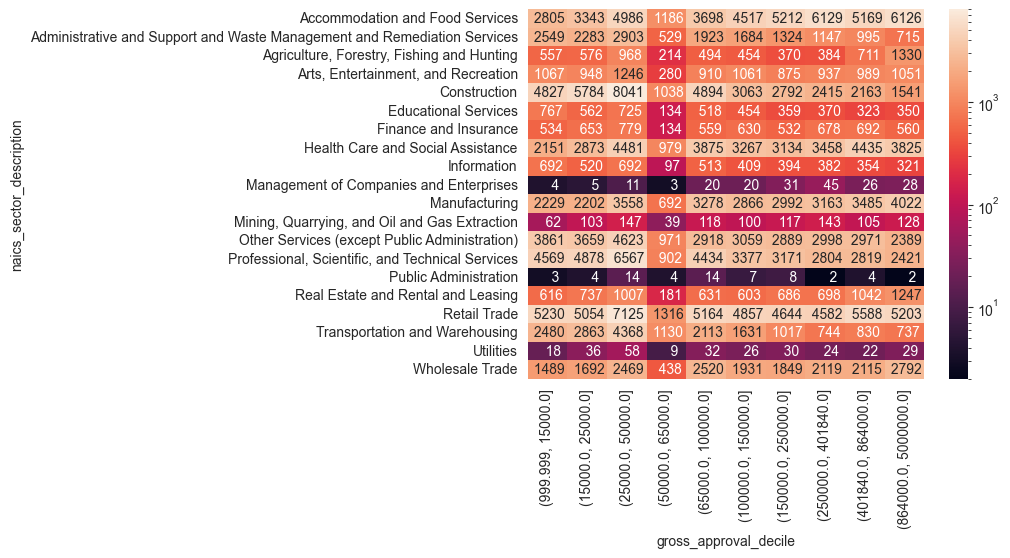

In [30]:
loan_count_by_sector_decile = df.pivot_table(
    index = 'naics_sector_description',
    columns = 'gross_approval_decile',
    values = 'is_default',
    aggfunc = 'count',
    fill_value = None
)

sns.heatmap(
    data = loan_count_by_sector_decile,
    cmap = 'rocket',
    norm = colors.LogNorm(),
    annot = True, fmt = '5'
)

plt.show()

In [31]:
default_rate_by_sector_decile.describe()

gross_approval_decile,"(999.999, 15000.0]","(15000.0, 25000.0]","(25000.0, 50000.0]","(50000.0, 65000.0]","(65000.0, 100000.0]","(100000.0, 150000.0]","(150000.0, 250000.0]","(250000.0, 401840.0]","(401840.0, 864000.0]","(864000.0, 5000000.0]"
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,0.08,0.10,0.07,0.06,0.06,0.08,0.06,0.07,0.05,0.05
std,0.04,0.05,0.04,0.03,0.02,0.04,0.03,0.03,0.03,0.04
min,0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.08,0.07,0.06,0.05,0.05,0.06,0.05,0.05,0.04,0.04
50%,0.09,0.08,0.07,0.06,0.07,0.08,0.06,0.07,0.06,0.05
75%,0.11,0.11,0.08,0.08,0.08,0.10,0.08,0.08,0.06,0.07
max,0.13,0.25,0.21,0.11,0.10,0.14,0.12,0.11,0.10,0.15


In [32]:
df['gross_approval'].describe()

count     348,274.00
mean      324,304.05
std       600,265.35
min         1,000.00
25%        33,500.00
50%       100,000.00
75%       325,000.00
max     5,000,000.00
Name: gross_approval, dtype: float64

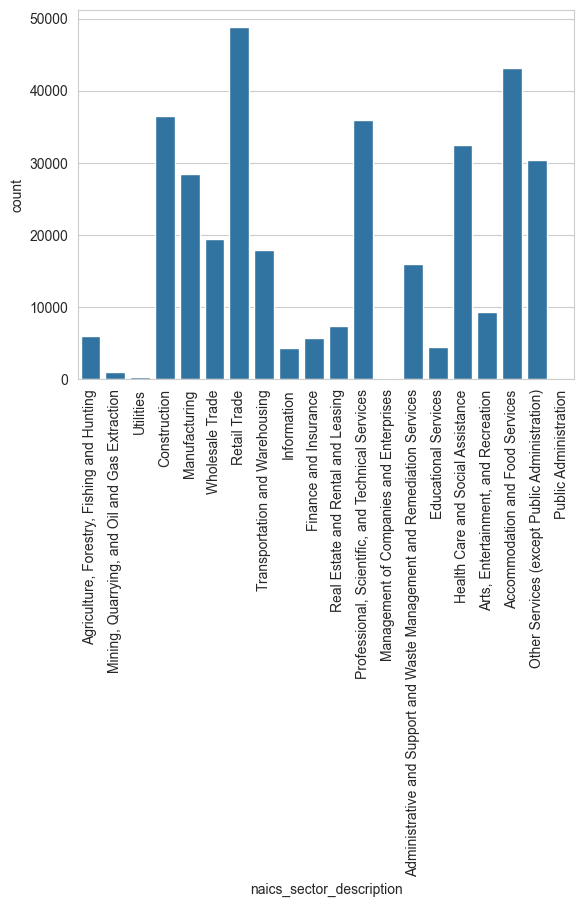

In [33]:
sns.countplot(
    data = df,
    x = 'naics_sector_description'
)

plt.xticks(rotation=90)
plt.show()

In [34]:
retail_only = df[df['naics_sector_description'] == 'Retail Trade']
retail_test_loan_size = pd.crosstab(retail_only['gross_approval_decile'], retail_only['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
retail_test_loan_size

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4553,677
"(15000.0, 25000.0]",4525,529
"(25000.0, 50000.0]",6509,616
"(50000.0, 65000.0]",1205,111
"(65000.0, 100000.0]",4745,419
"(100000.0, 150000.0]",4331,526
"(150000.0, 250000.0]",4212,432
"(250000.0, 401840.0]",4219,363
"(401840.0, 864000.0]",5252,336


In [35]:
scipy.stats.chi2_contingency(observed = retail_test_loan_size)

Chi2ContingencyResult(statistic=np.float64(289.1593479027879), pvalue=np.float64(5.189721039896383e-57), dof=9, expected_freq=array([[4769.45368415,  460.54631585],
       [4608.95199229,  445.04800771],
       [6497.5826959 ,  627.4173041 ],
       [1200.1149232 ,  115.8850768 ],
       [4709.2655497 ,  454.7344503 ],
       [4429.29953038,  427.70046962],
       [4235.05600558,  408.94399442],
       [4178.51563686,  403.48436314],
       [5095.92871644,  492.07128356],
       [4744.83126551,  458.16873449]]))

In [36]:
# Removing the outlier decile, (100,000-150,000] to ensure test results are not skewed in favor of significance.

retail_excl_sixth_decile = retail_only[retail_only['gross_approval_decile'] != pd.Interval(100000, 150000, closed='right')]
retail_test_excl_outlier = pd.crosstab(retail_excl_sixth_decile['gross_approval_decile'], \
                                       retail_excl_sixth_decile['is_default']) \
                                        .rename(columns={0: 'Non-Default', 1: 'Default'})
retail_test_excl_outlier

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4553,677
"(15000.0, 25000.0]",4525,529
"(25000.0, 50000.0]",6509,616
"(50000.0, 65000.0]",1205,111
"(65000.0, 100000.0]",4745,419
"(150000.0, 250000.0]",4212,432
"(250000.0, 401840.0]",4219,363
"(401840.0, 864000.0]",5252,336
"(864000.0, 5000000.0]",4918,285


In [37]:
scipy.stats.chi2_contingency(observed = retail_test_excl_outlier)

Chi2ContingencyResult(statistic=np.float64(267.8130665952005), pvalue=np.float64(2.865174850287855e-53), dof=8, expected_freq=array([[4781.16293901,  448.83706099],
       [4620.26720722,  433.73279278],
       [6513.53459664,  611.46540336],
       [1203.06126725,  112.93873275],
       [4720.82703958,  443.17296042],
       [4245.45328657,  398.54671343],
       [4188.77410832,  393.22589168],
       [5108.43948435,  479.56051565],
       [4756.48007106,  446.51992894]]))

In [54]:
construction_only = df[df['naics_sector_description'] == 'Construction']
construction_test_loan_size = pd.crosstab(construction_only['gross_approval_decile'], construction_only['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
construction_test_loan_size

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4458,369
"(15000.0, 25000.0]",5341,443
"(25000.0, 50000.0]",7431,610
"(50000.0, 65000.0]",975,63
"(65000.0, 100000.0]",4529,365
"(100000.0, 150000.0]",2753,310
"(150000.0, 250000.0]",2603,189
"(250000.0, 401840.0]",2229,186
"(401840.0, 864000.0]",1986,177


In [55]:
scipy.stats.chi2_contingency(observed = construction_test_loan_size)

Chi2ContingencyResult(statistic=np.float64(34.6097729063652), pvalue=np.float64(6.980273189948855e-05), dof=9, expected_freq=array([[4451.61948137,  375.38051863],
       [5334.19661907,  449.80338093],
       [7415.67686963,  625.32313037],
       [ 957.27802396,   80.72197604],
       [4513.40910334,  380.59089666],
       [2824.80018054,  238.19981946],
       [2574.87499316,  217.12500684],
       [2227.19309043,  187.80690957],
       [1994.79033317,  168.20966683],
       [1421.16130532,  119.83869468]]))

In [40]:
construct_excl_sixth_decile = construction_only[construction_only['gross_approval_decile'] != pd.Interval(100000, 150000, closed='right')]
construct_test_excl_outlier = pd.crosstab(construct_excl_sixth_decile['gross_approval_decile'], \
                                       construct_excl_sixth_decile['is_default']) \
                                        .rename(columns={0: 'Non-Default', 1: 'Default'})
construct_test_excl_outlier

is_default,Non-Default,Default
gross_approval_decile,,
"(999.999, 15000.0]",4458,369
"(15000.0, 25000.0]",5341,443
"(25000.0, 50000.0]",7431,610
"(50000.0, 65000.0]",975,63
"(65000.0, 100000.0]",4529,365
"(150000.0, 250000.0]",2603,189
"(250000.0, 401840.0]",2229,186
"(401840.0, 864000.0]",1986,177
"(864000.0, 5000000.0]",1410,131


In [41]:
scipy.stats.chi2_contingency(observed = construct_test_excl_outlier)

Chi2ContingencyResult(statistic=np.float64(9.229679993001458), pvalue=np.float64(0.3232926079891859), dof=8, expected_freq=array([[4461.96668159,  365.03331841],
       [5346.59525302,  437.40474698],
       [7432.9136289 ,  608.0863711 ],
       [ 959.50309001,   78.49690999],
       [4523.89992536,  370.10007464],
       [2580.85994925,  211.14005075],
       [2232.36990596,  182.63009404],
       [1999.42695925,  163.57304075],
       [1424.46460666,  116.53539334]]))

In [42]:
df[df['gross_approval'] == 150000].groupby('approval_fiscal_year')['is_default'].agg('count')

approval_fiscal_year
2010    1077
2011    1408
2012    1182
2013    1297
2014    2322
2015    3095
2016    3014
2017    3015
Name: is_default, dtype: int64

In [43]:
df[df['gross_approval'] == 150000].groupby('approval_fiscal_year')['term_in_months'].mean()

approval_fiscal_year
2010   84.33
2011   86.09
2012   89.94
2013   91.70
2014   94.46
2015   96.44
2016   94.11
2017   95.01
Name: term_in_months, dtype: float64

### Section Findings
- LogNorm was chosen as the distribution for the loan count heatmap since the loan count for a given pair can range from 2 to over 8000, a ratio well exceeding 100x.

- The $50K-65K bucket contains fewer loans overall since the preceding bucket is absorbing all of the $50K loans. All bins are right-closed, meaning the final value listed is included in the bin.

- Loans likely cluster at $150,000 due to program thresholds (maximum guaranty of 85% drops to 75% at $150,001, and fees are 2% here and increase to 3% at $150,001). I could not determine why the default rate increases at this loan size using the fields in this dataframe or searching outside sources.

#### Retail Prior
- Retail's loan size distribution is fairly uniform, with the exception of the $50K-$65K bucket.

- Retail's default rates per decile show a clear downward trend, beginning at 13% for the lowest decile and decreasing to 5.5% for the highest decile.

- The default rate of 11% in the $100K-$150K range appears to be an outlier as discussed.

- With an alpha of 0.05, our p-value of 5.19e-57 (and 2.87e-53 with the outlier decile removed) indicates a high level of significance, and we reject the null hypothesis.

- **My prior expecting Retail to be sensitive to loan size is supported by the data.** Admittedly, I did expect the effect to be inverted, with larger loans showing higher default rates, so I was wrong on that belief.

#### Construction Prior
- Loan counts generally decline across higher deciles.

- The wording in my prior may have been unclear. By calling Construction's impact from loan size "average", I meant it would have minimal sensitivity to loan size, displaying fairly consistent default rates across deciles that are near the portfolio mean (7.54%). I did not intend to imply that the sector's impact would resemble that of other industries, in which case we'd expect default rates to decrease with loan size.

- The data indicates loan size has minimal impact on Construction's default rates, although there is an outlier in the $100-150K decile and an uptick in the top two deciles. This goes against the trend most sectors have, with default rates decreasing as loan size rises.

- The initial contingency test had a p-value of 6.98e-05, meaning we would reject the null, which would have disproved my prior. However, after removing the ($100K,$150K] decile, the revised contingency test displayed a p-value of 0.32, indicating a lack of significance when the outlier is excluded.

- **My prior that Construction has low sensitivity to loan size is supported, once the $150K anomaly is excluded.**


## Assessment of Additional Model Features

### Revolver Status

In [44]:
revolver_count = df['revolver_status'].value_counts()
revolver_count_norm = df['revolver_status'].value_counts(normalize=True)
pd.concat([revolver_count, revolver_count_norm], axis = 1)

,count,proportion
revolver_status,,
False,232792,0.67
True,115482,0.33


In [45]:
df.groupby('revolver_status')[['is_default']].mean() \
    .rename(columns={'is_default':'default_rate'}).style.format({'default_rate': '{:.2%}'})

,default_rate
revolver_status,
False,7.78%
True,7.05%


In [46]:
revolver_contingency_test = pd.crosstab(df['revolver_status'], df['is_default']).rename(columns={0: 'Non-Default', 1: 'Default'})
revolver_contingency_test

is_default,Non-Default,Default
revolver_status,,
False,214682,18110
True,107346,8136


In [47]:
scipy.stats.chi2_contingency(observed = revolver_contingency_test)

Chi2ContingencyResult(statistic=np.float64(59.61233884199672), pvalue=np.float64(1.1550868615941462e-14), dof=1, expected_freq=array([[215248.74718182,  17543.25281818],
       [106779.25281818,   8702.74718182]]))

### Vintages

In [48]:
df.groupby('approval_fiscal_year')['is_default'].mean().to_frame().style.format({'is_default': '{:.2%}'})

,is_default
approval_fiscal_year,
2010,9.36%
2011,7.01%
2012,6.44%
2013,6.22%
2014,6.71%
2015,7.24%
2016,7.98%
2017,9.13%


### Term

In [53]:
df['term_decile'] = pd.qcut(df['term_in_months'], 5)
df['term_decile'].value_counts()

ValueError: Bin edges must be unique: Index([1.0, 60.0, 84.0, 84.0, 120.0, 324.0], dtype='float64', name='term_in_months').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [56]:
df.groupby('revolver_status')[['gross_approval','term_in_months']].median()

,gross_approval,term_in_months
revolver_status,,
False,"180,000.00",120.00
True,"40,000.00",84.00
